# 타이타닉 EDA 리포트

**작성자** :   
**작성일** : 

---

> 이 노트북은 **EDA 리포트** 형식입니다.  
> 코드를 돌리는 것으로 끝내지 말고, 각 섹션의 마크다운 셀에 **해석을 남기세요.**

### 목차

| 섹션 | 내용 |
|---|---|
| 0 | 준비 — 라이브러리와 데이터 |
| 1 | 분석 목적 및 질문 |
| 2 | 데이터 개요 |
| 3 | 데이터 품질 점검 — 결측치 |
| 4 | 상관관계 분석 |
| 5 | 그룹별 생존율 비교 |
| 6 | 요금 분포와 치우침 |
| 7 | 텍스트에서 파생변수 만들기 |
| 8 | 통계 검정 |
| 9 | 발견 사항 · 다음 단계 · 한계 |

## 0. 준비

In [2]:
import numpy as np
import pandas as pd

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
import warnings; warnings.filterwarnings('ignore')

In [5]:
# 그래프 폰트 설정
import matplotlib
from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지
print('font:', plt.rcParams['font.family'])

font: ['Malgun Gothic']


### 데이터 불러오기

In [6]:
FILE_PATH = 'titanic.csv'
df = pd.read_csv(FILE_PATH)

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


---

## 1. 분석 목적

**이 분석으로 무엇을 알고 싶은지 한 문장으로 적으세요.**

**분석 목적** : 타이타닉 승객의 생존을 가르는 요인을 찾고, 이후 모델에 사용할 변수를 선별하는 것

---

## 2. 데이터 개요

크기 · 타입 · 기초 통계량을 확인합니다.

In [5]:
df.shape

(891, 12)

In [7]:
df.head(2).T

,0,1
PassengerId,1,2
Survived,0,1
Pclass,3,1
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th..."
Sex,male,female
Age,22.0,38.0
SibSp,1,1
Parch,0,0
Ticket,A/5 21171,PC 17599
Fare,7.25,71.2833


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.describe(include='all')

In [13]:
df.describe(include='O')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**여기서 확인 가능한 것**

- 행/열 수 : 891/12
- 결측이 있는 컬럼 : Age, Cabin, Embarked
- 평균과 중앙값이 크게 다른 컬럼 : Fare
- 타깃(`Survived`) 의 비율 : 38.4%

### 변수 사전

각 컬럼의 의미와 유형을 정리하세요. **이 표가 이후 모든 분석 선택의 기준**이 됩니다.

| 컬럼 | 의미 | 유형 | 결측 |
|---|---|---|---|
| PassengerId | 승객 번호 | 식별자 | 0 |
| Survived | 생존 여부 0/1 — **타깃** | 범주형-명목(이진) | 0 |
| Pclass | 객실 등급 1~3 | 범주형-순서 | 0 |
| Name | 이름 (호칭 포함) | 텍스트 | 0 |
| Sex | 성별 | 범주형-명목 | 0 |
| Age | 나이 | 수치형-연속 | 177 |
| SibSp | 동승 형제·배우자 수 | 수치형-이산 | 0 |
| Parch | 동승 부모·자녀 수 | 수치형-이산 | 0 |
| Ticket | 티켓 번호 | 식별자 | 0 |
| Fare | **티켓 단위** 요금 합계 | 수치형-연속 | 0 |
| Cabin | 객실 번호 | 텍스트 | 687 |
| Embarked | 승선 항구 S/C/Q | 범주형-명목 | 2 |

> 유형 후보 : 수치형-연속 / 수치형-이산 / 범주형-명목 / 범주형-순서 / 식별자 / 텍스트

---

## 3. 데이터 품질 점검 — 결측치

결측은 **얼마나** 비었는지보다 **왜** 비었는지가 중요합니다.
처리 방법은 그 판단에서 갈립니다.

In [17]:
# TODO 결측 개수와 비율을 구해 보세요.  isna().sum() / isna().mean() 활용
na = pd.DataFrame({
    '결측 수': df.isna().sum(),
    '결측률(%)': (df.isna().mean() * 100).round(1)
})
na[na['결측 수'] > 0]

,결측 수,결측률(%)
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


In [25]:
# TODO Cabin 결측률을 객실등급(Pclass)별로 나눠 보세요.
#       결측이 무작위인지 아닌지가 여기서 드러납니다.
df.groupby('Pclass')['Cabin'].apply(lambda s : s.isna().mean()*100 ).round(1)

Pclass
1    18.5
2    91.3
3    97.6
Name: Cabin, dtype: float64

**처리 계획**

| 컬럼 | 결측 | 처리 방법 | 근거 |
|---|---|---|---|
| Age | 177 (19.9%) | Pclass×Sex 그룹 중앙값으로 대체 | 결측이 등급으로 설명됨. 전체 평균 대체는 같은 값을 한 점에 몰아넣어 표준편차를 약 10% 줄인다 (분산 과소추정) |
| Cabin | 687 (77.1%) | 원본 열은 제외하되 **`HasCabin` 이진 변수로 전환** | 결측이 3등석에 집중 — 기록 여부가 등급·생존을 설명하는 정보 |
| Embarked | 2 (0.2%) | 최빈값 `S` 로 대체 | 2건뿐이라 영향이 미미하고 S가 전체의 약 72%를 차지 |

In [26]:
# TODO 위 계획대로 결측을 처리해 보세요.
print('처리 전 std:', round(df['Age'].std(), 2))
a = df['Age'].fillna(df['Age'].mean())
print('평균 대체 처리 후 std:', round(a.std(), 2))

b = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
print('그룹 대체 처리 후 std:', round(b.std(), 2))

df['Age'] = b

처리 전 std: 14.53
평균 대체 처리 후 std: 13.0
그룹 대체 처리 후 std: 13.3


In [44]:
df['HasCabin'] = df['Cabin'].isna().astype(int)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

---

## 4. 요금 분포와 치우침

요금의 분포를 시각화해보세요.

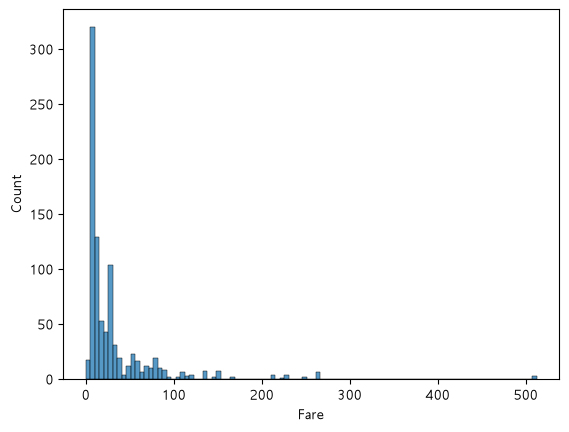

In [64]:
# TODO Fare 의 히스토그램을 그려 보세요.
g = sns.histplot(df, x='Fare', bins=100)

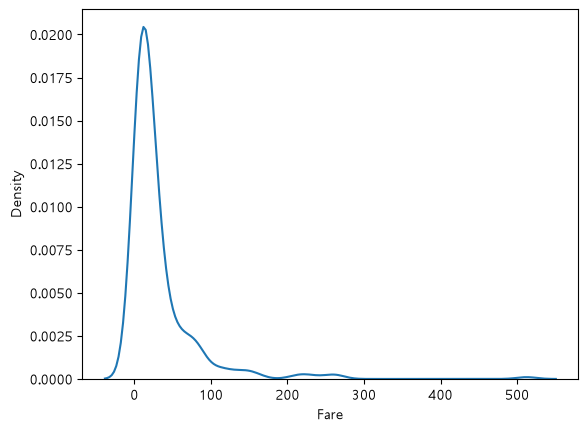

In [65]:
# 밀도 곡선
g = sns.kdeplot(df["Fare"])

In [ ]:
# TODO Fare 의 왜도(skewness)를 구해 보세요.
df['Fare'].skew().item()
# numeric_only=True

4.787316519674893

skewness는 -2 이하, 2 이상이 기준

치우침(Skewness)가 가장 심한 feature가 무엇인지 찾아보세요.

,skew,feature
Fare,4.787317,Fare
SibSp,3.695352,SibSp
Parch,2.749117,Parch
Age,0.534083,Age
Survived,0.478523,Survived
Pclass,-0.630548,Pclass
HasCabin,-1.292367,HasCabin


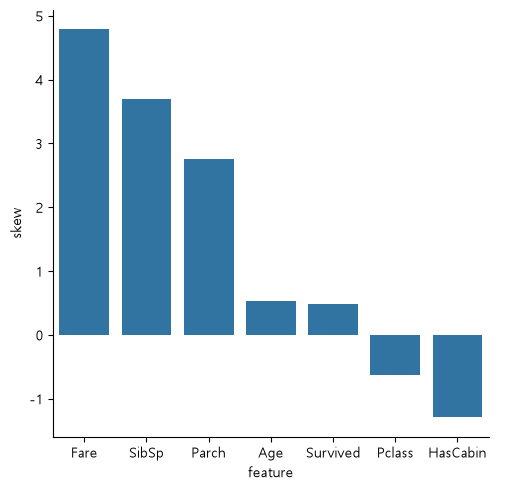

In [ ]:
# TODO 전체 수치형 컬럼의 왜도를 구해 정렬하고, 표와 막대그래프로 만들어 보세요. 
# 순서
# 1. skew(numeric_only=True), 내림차순 정렬
# 2. 데이터프레임 생성 (skew, feature)
# 3. display(), sns.catplot()
skew = df.skew(numeric_only=True).sort_values(ascending=False).drop(['PassengerId'])

skew_df = pd.DataFrame(skew, columns=['skew'])
skew_df['feature'] = skew_df.index
display(skew_df)

g = sns.catplot(skew_df, x='feature', y='skew', kind='bar')

첨도(Kurtosis)가 가장 심한 feature가 무엇인지 찾아보세요.

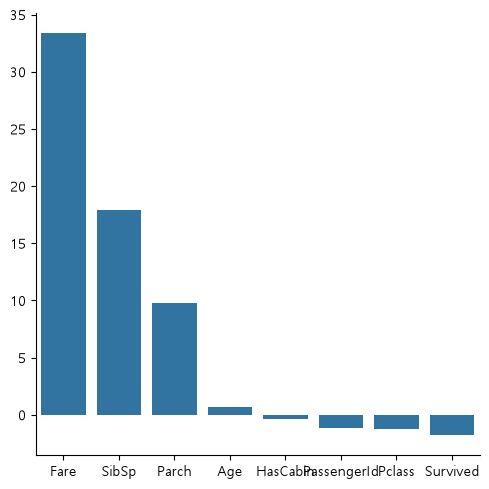

In [85]:
# TODO 첨도를 구해 정렬해 보세요.
kurt = df.kurt(numeric_only=True).sort_values(ascending=False)

g = sns.catplot(kurt, kind='bar')

- **왜도(skew)** — 치우친 정도. `Fare` 가 압도적으로 큽니다 (약 4.8)  
  오른쪽 꼬리가 길다는 뜻이고, 이래서 평균 > 중앙값이 됩니다
- **첨도(kurtosis)** — 뾰족한 정도, 꼬리의 두께. 극단값이 얼마나 자주 나타나는가

**처리 방향**

- 왜도가 크면 **로그 변환**을 검토합니다. `np.log1p(Fare)` 를 쓰면 왜도가 크게 줄어듭니다.

**왜 이렇게 긴 꼬리가 생겼을까**

In [87]:
# TODO 같은 Ticket을 공유한 인원수를 세는 GroupSize 를 만들어 보세요.
df['GroupSize'] = df.groupby('Ticket')['Ticket'].transform('size')

1인당 요금으로 바꾸면 왜도가 줄어드는가

In [89]:
# TODO 1인당 요금 FarePerPerson 을 만들어 보세요.
df['FarePerPerson'] = df['Fare'] / df['GroupSize']

In [95]:
# TODO Fare 와 FarePerPerson 의 왜도·첨도를 나란히 비교해 보세요.
print('왜도: skew')
display(df[['Fare', 'FarePerPerson']].skew())
print('첨도: kurt')
display(df[['Fare', 'FarePerPerson']].kurt())

왜도: skew


Fare             4.787317
FarePerPerson    4.380561
dtype: float64

첨도: kurt


Fare             33.398141
FarePerPerson    28.578439
dtype: float64

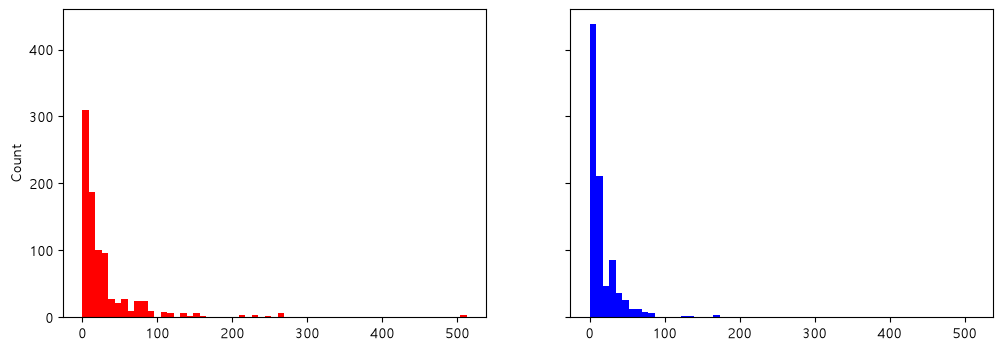

In [ ]:
# TODO 두 분포를 히스토그램 두 개로 나란히 그려 비교해 보세요.
#      ※ 축 범위를 통일해야 비교가 됩니다 (sharex)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

bins = np.linspace(0, df['Fare'].max(), 60)

axes[0].hist(df['Fare'], bins=bins, color='red')
axes[1].hist(df['FarePerPerson'], bins=bins, color='blue')
axes[0].set_ylabel('Count')

plt.show()

In [99]:
# TODO 두 feature의 기초 통계를 확인해보세요
df[['Fare', 'FarePerPerson']].describe()

,Fare,FarePerPerson
count,891.000000,891.000000
mean,32.204208,17.788989
std,49.693429,21.218157
min,0.000000,0.000000
25%,7.910400,7.762500
50%,14.454200,8.850000
75%,31.000000,24.288200
max,512.329200,221.779200


---

## 5. 단일 분포 & 그룹간 분포

생존자와 사망자 간의 각 나이 분포도를 히스토그램으로 시각화해보세요.

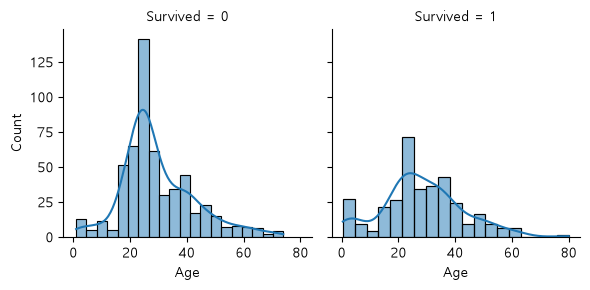

In [100]:
# sns subplot 그리기 (col 기준) (row 기준)
g = sns.FacetGrid(df, col='Survived')
g = g.map(sns.histplot, 'Age', kde=True) # kernel density estimate to smooth the distribution and show on the plot as (one or more) line(s)

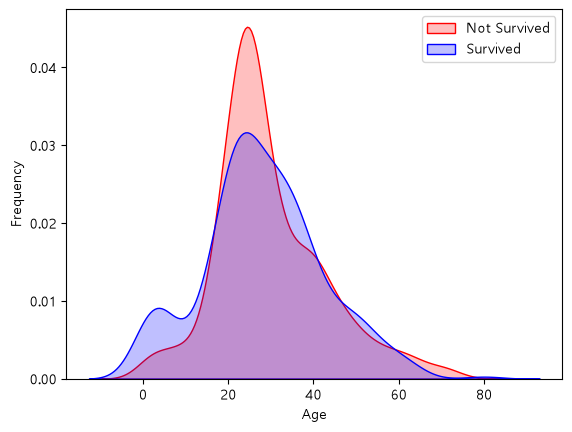

In [101]:
# kde plot
g = sns.kdeplot(df["Age"][(df["Survived"] == 0) & (df["Age"].notnull())], color="Red", fill= True)
g = sns.kdeplot(df["Age"][(df["Survived"] == 1) & (df["Age"].notnull())], ax =g, color="Blue", fill= True)
g.set_xlabel("Age")
g.set_ylabel("Frequency")
g = g.legend(["Not Survived", "Survived"])

**나이 분포에서 확인되는 것**

- 10세 미만 구간에서 생존률이 높다.

※ 그래프 그릴 때 주의사항: **축 범위를 통일**해야 비교가 가능

**Bar Plot**

['Pclass', 'SibSp', 'Parch'] 각각을 bar plot으로 시각화해보세요.

검은색 bar는 오차막대(error bar) 이며 신뢰구간(confidence interval) 95%

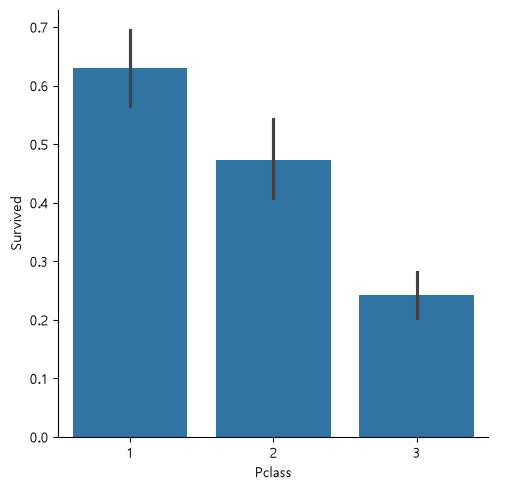

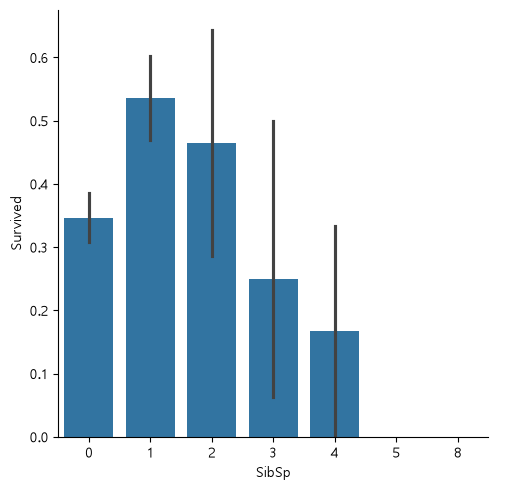

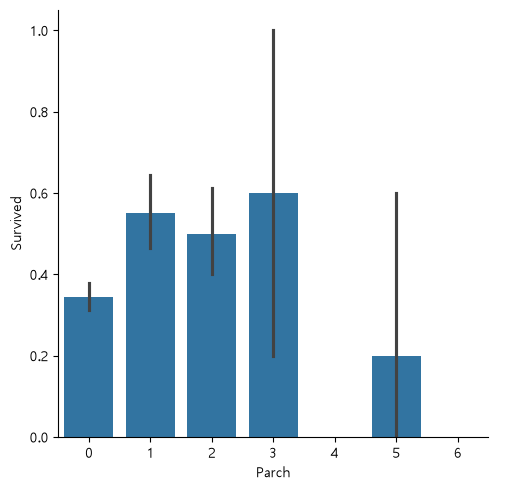

In [107]:
# TODO Pclass · SibSp · Parch 각각 생존율을 막대로 그려 보세요. sns.catplot(), kind=bar 활용
g = sns.catplot(df, x='Pclass', y='Survived', kind='bar')
g = sns.catplot(df, x='SibSp', y='Survived', kind='bar')
g = sns.catplot(df, x='Parch', y='Survived', kind='bar')

성별에 따른 생존율을 비교해보세요.  
남자 : 18.9%  
여자 : 74.2%

In [108]:
# TODO 성별 생존율을 비교해보세요.
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

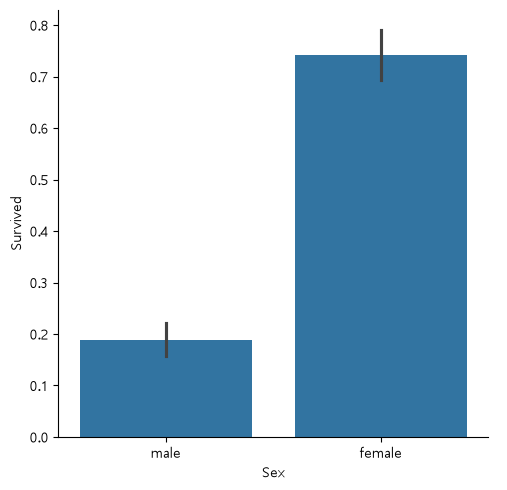

In [ ]:
g = sns.catplot(x='Sex', y='Survived', data=df, kind='bar')
plt.show()

객실등급에 따른 생존율을 비교해보세요.  
1등급 : 63.0%  
2등급 : 47.3%  
3등급 : 24.2%  

In [113]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

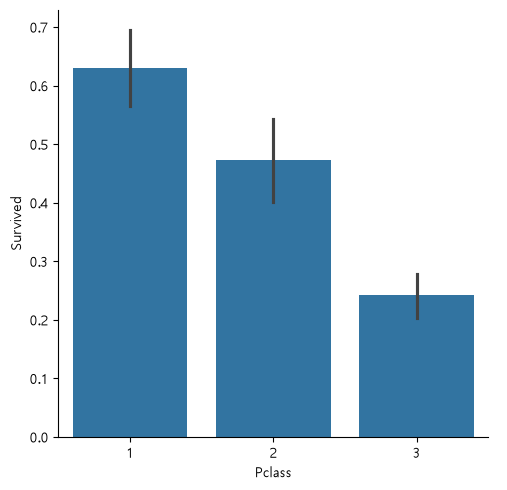

In [112]:
g = sns.catplot(x='Pclass', y='Survived', data=df, kind='bar')

하나의 그래프에 객실등급과 성별에 대한 생존율을 함께 시각화해보세요.

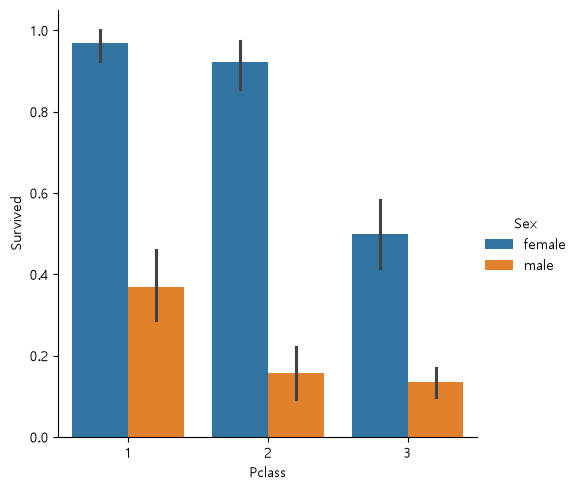

In [114]:
# TODO hue 파라미터로 등급 × 성별을 한 그래프에 그려 보세요.
g = sns.catplot(df, x='Pclass', y='Survived', hue='Sex', kind='bar')

**무엇을 알 수 있는가?**

1. 성별 격차가 전체 등급에서 유지가 된다.
2. 3등석 여성의 생존률조차 1등석 남성의 생존률보다 높다.

※결론: 성별과 등급은 각각 독립적으로 생존에 작용한다.

성별에 따른 나이의 분포를 분석해보세요.  
객실등급에 따른 나이의 분포를 분석해보세요.

In [115]:
df[['Age', 'Sex']].groupby(['Sex']).mean()

,Age
Sex,
female,27.261146
male,30.119879


In [116]:
df[['Age', 'Pclass']].groupby(['Pclass']).mean()

,Age
Pclass,
1,38.270463
2,29.863207
3,24.802281


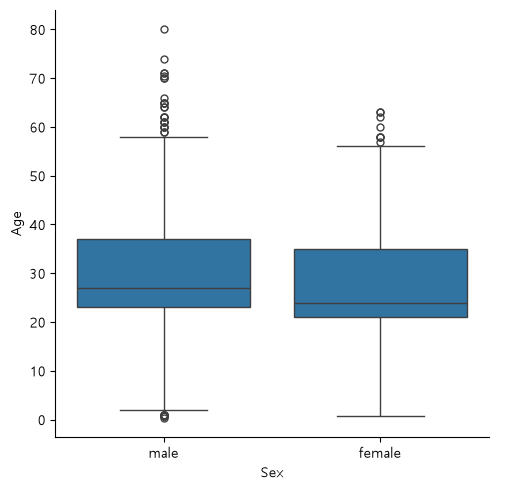

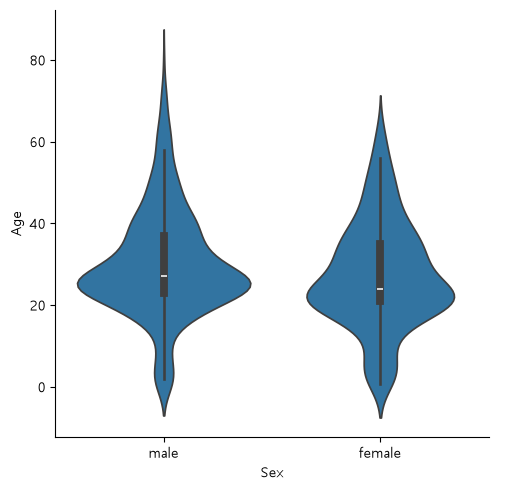

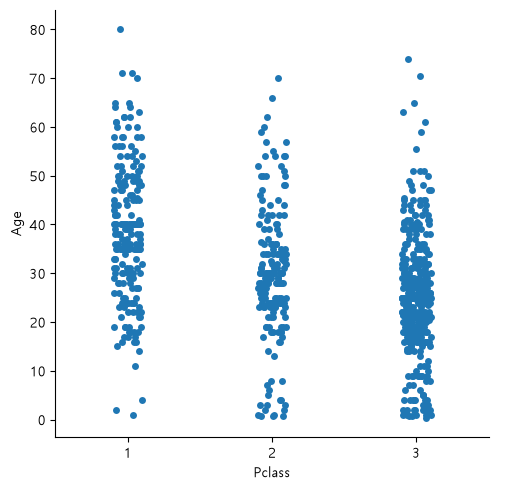

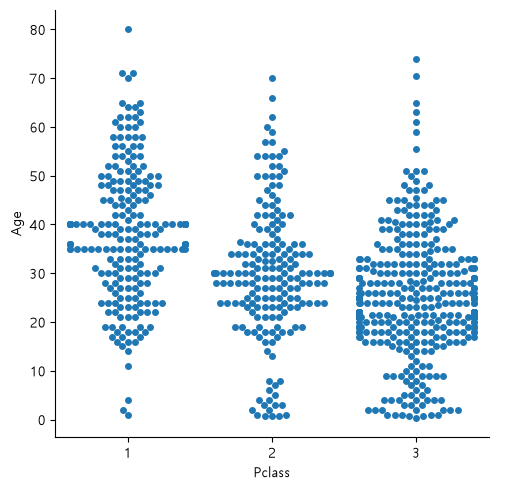

In [118]:
# TODO box · violin · strip · swarm 네 가지로 그려 비교해 보세요. sns.catplot()에 kind만 변경. Sex, Pclass 2개씩 적용
g = sns.catplot(df, x='Sex', y='Age', kind='box')
g = sns.catplot(df, x='Sex', y='Age', kind='violin')
g = sns.catplot(df, x='Pclass', y='Age', kind='strip')
g = sns.catplot(df, x='Pclass', y='Age', kind='swarm')

**네 가지 그래프의 차이**

| 종류 | 보여주는 것 | 한계 |
|---|---|---|
| `box` | 5수 요약 + 이상치 | 봉우리가 두 개인 분포를 놓친다 |
| `violin` | 분포의 **형태**까지 | 표본이 적으면 과장된다 |
| `strip` | 개별 점 전부 | 점이 겹친다 |
| `swarm` | 겹치지 않게 배치한 개별 점 | 데이터가 많으면 느리고 경고가 뜬다 |

**등급이 높을수록 평균 나이가 많습니다.** 경제력과 연령의 관계로 해석할 수 있습니다.  
이 사실은 `Age` 결측을 **등급별로** 채운 근거와 연결됩니다.

항구에 따른 생존율을 시각화해보세요.

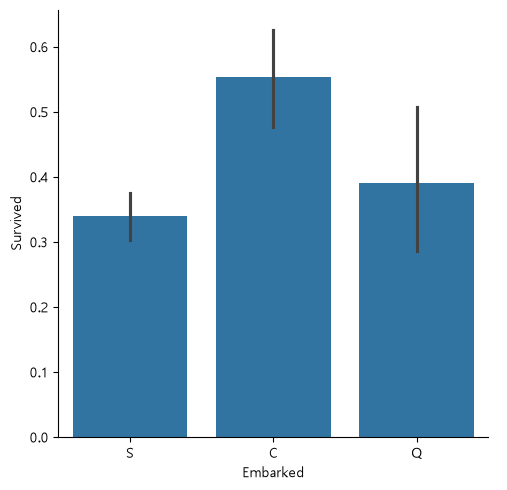

In [119]:
# TODO 승선 항구별 생존율을 그려 보세요.
g = sns.catplot(df, x='Embarked', y='Survived', kind='bar')

항구에 따라 생존율의 차이가 있습니다.  
왜일까?  
항구에 따라 탑승하는 객실등급 수준의 차이가 있는건 아닐까?

In [120]:
# TODO 항구별 평균 객실등급을 확인해 보세요.
df.groupby('Embarked')['Pclass'].mean()

Embarked
C    1.886905
Q    2.909091
S    2.346749
Name: Pclass, dtype: float64

In [121]:
count_em_pc = df[['Pclass', 'Embarked', 'PassengerId']].groupby(['Embarked', 'Pclass']).count()
count_em_pc

PassengerId
Embarked Pclass             
C        1                85
         2                17
         3                66
Q        1                 2
         2                 3
         3                72
S        1               129
         2               164
         3               353

  count plot을 이용해서 표현해보자.

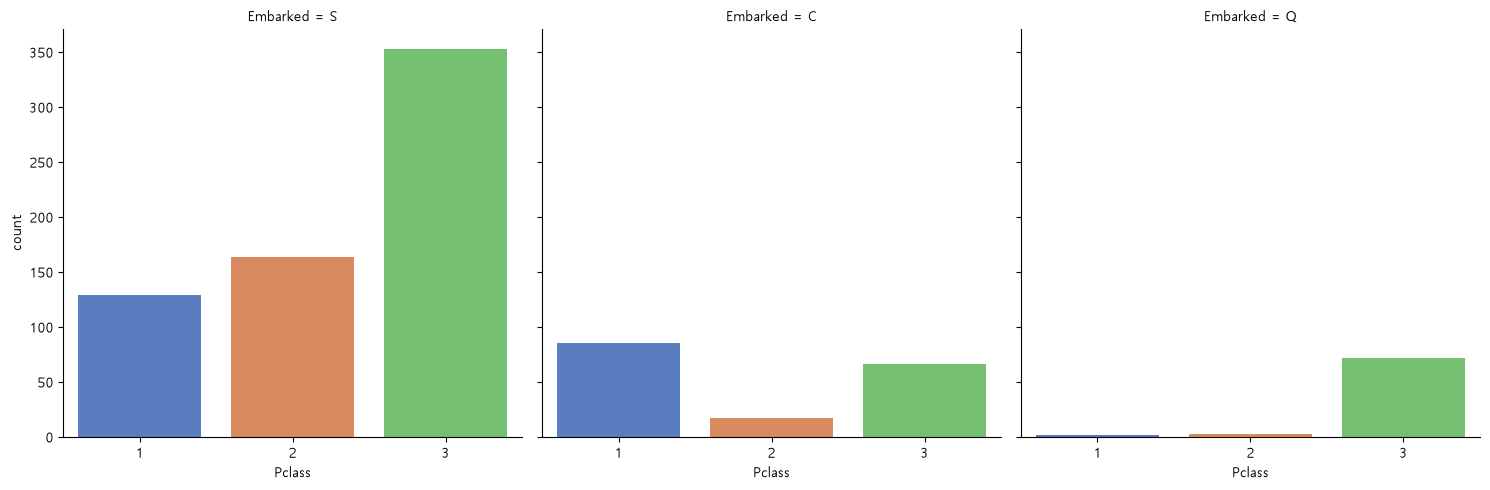

In [122]:
g = sns.catplot(x="Pclass", col="Embarked",  data=df,
                   kind="count", palette="muted")

항구와 객실등급에 따른 생존율

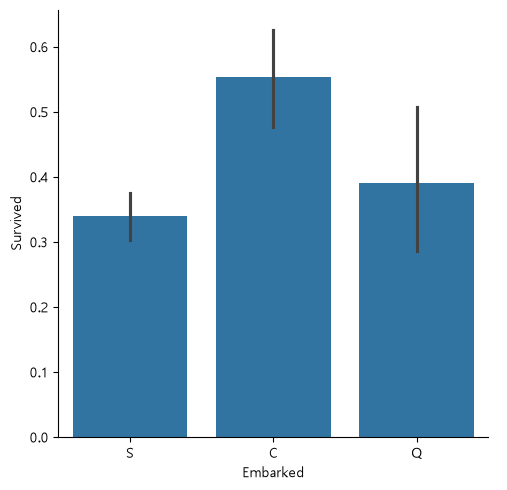

In [123]:
g = sns.catplot(x='Embarked', y='Survived', data=df, kind='bar',
                   aspect=1)

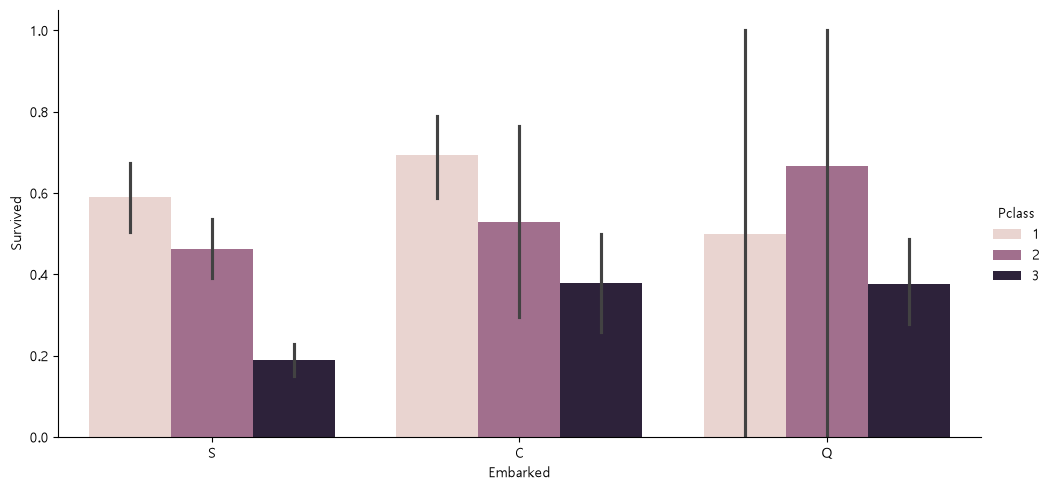

In [130]:
# TODO 항구 × 등급으로 나눠 생존율을 그려 보세요.
g = sns.catplot(df, x='Embarked', y='Survived', hue='Pclass', kind='bar', aspect=2)

**교란변수(confounder)를 잡아낸 순간입니다.**

C 항구의 생존율이 높았던 것은 **항구 자체의 효과가 아니라**,  
C에서 1등석 승객이 많이 탔기 때문입니다.

등급으로 나눠 보면 항구 간 차이가 크게 줄어듭니다.


> **합쳐서 본 값과 나눠서 본 값이 다르면 교란변수가 숨어 있습니다.**  
> 전체 수치를 보고할 때는 주요 그룹으로 분해해도 결론이 유지되는지 확인해야 합니다.

---

## 6. 상관관계 분석

생존율과 객실등급 간의 상관관계를 분석해보세요.

In [131]:
col = list(df)
col.pop(0)

'PassengerId'

In [ ]:
col

In [135]:
# col.insert(0, col.pop())

In [ ]:
df[col[:3]]

In [ ]:
df[:5]

In [ ]:
# TODO Survived 와 Pclass 의 상관계수를 구해 보세요. corr() 메서드 활용
df[ ['Survived', 'Pclass'] ].corr() # method='spearman'

,Survived,Pclass
Survived,1.000000,-0.338481
Pclass,-0.338481,1.000000


생존율과 다음 컬럼값들 간의 상관관계를 분석해보세요.  
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

상관관계 > Table로 표현해보세요.

In [141]:
# TODO Survived 열만 뽑아 상관계수 표를 만들어 보세요.
df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].corr()['Survived']

Pclass     -0.338481
Age        -0.059579
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64

상관관계 > heatmap으로 표현해보세요.

In [161]:
masks = np.ones((len(corr_df), len(corr_df)), dtype=bool)
for i in range(len(masks)):
    for j in range(len(masks)):
        if i > j:
            masks[i, j] = False
masks

array([[ True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True],
       [False, False, False, False,  True,  True],
       [False, False, False, False, False,  True]])

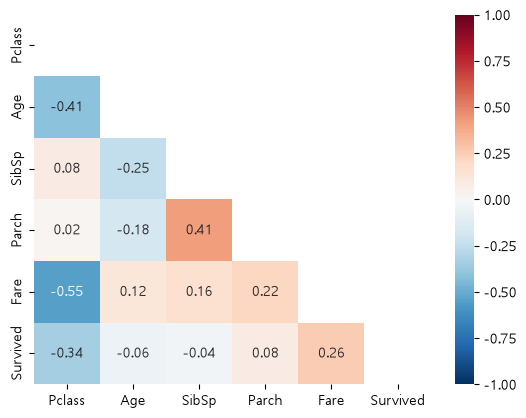

In [ ]:
# TODO 히트맵으로 그려 보세요.  sns.heatmap() 활용, cmap: coolwarm, annot(레이블): 활성화, fmt(포맷): 소숫점 아래 2번째 까지
corr_df = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].corr()

masks = np.triu(np.ones_like(corr_df, dtype=bool), 1)
masks = masks | np.eye(len(masks), dtype=bool)

g = sns.heatmap(corr_df, vmin=-1, vmax=1, cmap='RdBu_r', 
                annot=True, fmt='.2f', mask=masks)

---

## 7. 통계 검정

지금까지는 **눈으로 본 차이**입니다. 우연으로 볼 수 있는지 숫자로 확인합니다.

| 묻고 싶은 것 | 변수 유형 | 검정 |
|---|---|---|
| 두 그룹의 평균이 다른가? | 그룹(2) × 수치 | 독립표본 t-검정 |
| 세 그룹 이상의 평균이 다른가? | 그룹(3+) × 수치 | ANOVA |
| 두 범주가 관련 있는가? | 범주 × 범주 | 카이제곱 |

In [ ]:
# %pip install scipy

In [164]:
from scipy import stats

In [181]:
# TODO 가설 1 — 성별과 생존은 관련이 있다 (범주 × 범주 → 카이제곱) stats.chi2_contingency
tab = pd.crosstab(df['Sex'], df['Survived'])

# 크기
female, male = df.groupby('Sex')['Survived'].mean()
print(f'여성 생존률: {female*100:.2f}%, 남성 생존률: {male*100:.2f}%, 차이 ({(female-male)*100:.2f}%p)')

# 검정
chi2, p, dof, _ = stats.chi2_contingency(tab)
print(f'chi2: {chi2:.2f}, p-value: {p}')

여성 생존률: 74.20%, 남성 생존률: 18.89%, 차이 (55.31%p)
chi2: 260.72, p-value: 1.1973570627755645e-58


In [180]:
# TODO 가설 2 — 생존/사망 그룹의 평균 요금이 다르다 (그룹2 × 수치 → t-검정) stats.ttest_ind
alive = df[df['Survived'] == 1]['Fare']
dead  = df[df['Survived'] == 0]['Fare']
print(f'생존: {alive.mean():.2f}, 사망: {dead.mean():.2f}, 차이: +{alive.mean()-dead.mean():.2f}')

t, p2 = stats.ttest_ind(alive, dead, equal_var=False)
print(f't = {t:.2f}, p-value: {p2}')

생존: 48.40, 사망: 22.12, 차이: +26.28
t = 6.84, p-value: 2.6993323503141203e-11


In [185]:
# TODO 가설 3 — 객실등급별 평균 나이가 다르다 (그룹3+ × 수치 → ANOVA) stats.f_oneway
groups = [df[df['Pclass'] == pc]['Age'] for pc in [1, 2, 3]]
for pc, group in enumerate(groups, start=1):
    print(f'{pc}등급 평균 나이: {group.mean():.2f}')

f, p3 = stats.f_oneway(*groups)
print(f'f = {f:.2f}, p-value: {p3}')

1등급 평균 나이: 38.27
2등급 평균 나이: 29.86
3등급 평균 나이: 24.80
f = 93.24, p-value: 1.751457020013721e-37


**해석 문장** — p값만 적지 말고 **차이의 실제 크기**를 함께 쓰세요.

1. 여성의 생존율이 남성보다 약 **55.3%p** 높았다. (카이제곱, p-value< 0.001). 우연으로 보기 힘들다.
2. 생존자의 평균 요금이 사망자보다 약 **26** 높았다. (t-검정, p-value < 0.001). 객실등급의 영향이 있을 수 있다.
3. 객실등급별 평균 나이에는 차이가 있다. (ANOVA, p-value < 0.001). 1등급의 평균나이가 가장 크다.

---

## 8. 텍스트에서 파생변수 만들기

In [ ]:
df.head()

In [187]:
df[['Name', 'Ticket', 'Cabin']].describe()

,Name,Ticket,Cabin
count,891,891,204
unique,891,681,147
top,"Braund, Mr. Owen Harris",347082,G6
freq,1,7,4


Name, Ticket, Cabin은 모두 unique값이 많기 때문에, 데이터 자체값으로는 큰의미가 없다. 

데이터를 직접 살펴보고, 유의미한 value를 추출할 수 있을지 고민해야한다.

In [191]:
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

전체 이름에서, . 앞에 있는 알파벳묶음열(알파벳으로만 이루어진 문자열)을 찾아내고 싶다면?

In [2]:
# .
# ?
# +
# *
# []
# [^]
# ()

# 이스케이프 시퀀스 \. \? \+ \* \[ \] \^ \( \)

# greedy Q : 최대한 긴 문자열로 찾아낸다. = .+
# lazy Q : 최대한 짧은 문자열로 찾아낸다. = .+?

In [192]:
import re
text = 'abc.def..ght..xyz.poi'
lq = re.findall(r'\.(.+?)\.', text)
gq = re.findall(r'\.(.+)\.', text)
lq, gq

(['def', 'ght', 'xyz'], ['def..ght..xyz'])

In [ ]:
# TODO 정규표현식으로 이름에서 호칭(Title)을 추출해 보세요. df.str.extract() 메서드 활용
# Cumings, Mrs. John Bradley (Florence Briggs Th...
# Graham, Miss. Margaret Edith

In [200]:
df['Name'].str.extract(r'(\w+)\.')[0].unique()

<StringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer']
Length: 17, dtype: str

In [ ]:
# TODO 쉼표 뒤 ~ 마침표 앞을 뽑는 방식으로도 해 보세요.
df['Title'] = df['Name'].str.extract(r'\,\s(.+?)\.')

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Name, Length: 891, dtype: str

In [207]:
# TODO Title 을 Sex · Pclass · Survived 와 각각 교차표로 확인해 보세요. pd.crosstab() 활용
display(pd.crosstab(df['Title'], df['Sex']))
display(pd.crosstab(df['Title'], df['Pclass']))
display(pd.crosstab(df['Title'], df['Survived']))

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40
Miss,182,0


Pclass,1,2,3
Title,,,
Capt,1,0,0
Col,2,0,0
Don,1,0,0
Dr,5,2,0
Jonkheer,1,0,0
Lady,1,0,0
Major,2,0,0
Master,3,9,28
Miss,46,34,102


Survived,0,1
Title,,
Capt,1,0
Col,1,1
Don,1,0
Dr,4,3
Jonkheer,1,0
Lady,0,1
Major,1,1
Master,17,23
Miss,55,127


In [208]:
list(df)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked',
 'HasCabin',
 'GroupSize',
 'FarePerPerson',
 'Title']

In [211]:
df['Name'].str.split(',')

0                             [Braund,  Mr. Owen Harris]
1      [Cumings,  Mrs. John Bradley (Florence Briggs ...
2                              [Heikkinen,  Miss. Laina]
3        [Futrelle,  Mrs. Jacques Heath (Lily May Peel)]
4                            [Allen,  Mr. William Henry]
                             ...                        
886                             [Montvila,  Rev. Juozas]
887                      [Graham,  Miss. Margaret Edith]
888          [Johnston,  Miss. Catherine Helen "Carrie"]
889                             [Behr,  Mr. Karl Howell]
890                               [Dooley,  Mr. Patrick]
Name: Name, Length: 891, dtype: object

이름에서 Mr, Miss 등 성별 혹은 직위를 나타내는 칭호가 있다. 이것은 생존율에 쓸만하지 않을까?

  이녀석만 따로 빼내자.

In [ ]:
[i.split(",")[1] for i in df["Name"]]

In [ ]:
# TODO 문자열 split 만으로도 Title 을 뽑아 보세요 (정규식 없이).
df['Name'].apply(lambda s: s.split(',')[1].split('.')[0].strip())

**정규식 vs split — 둘 다 결과는 같다**

- 정규식 : 패턴이 복잡해질수록 유리. 대신 읽기 어렵다
- split : 구분자가 단순하면 더 직관적

실무에서는 **읽기 쉬운 쪽**을 고르면 됩니다.  
다만 `.strip()` 을 빼먹으면 `' Mr'` 처럼 공백이 남아 그룹이 어긋납니다.

Title에 따른 생존율을 비교해보세요.

In [219]:
# TODO Title 별 생존율을 구해 보세요.
df[['Title', 'Survived']].groupby('Title').mean()

,Survived
Title,
Capt,0.000000
Col,0.500000
Don,0.000000
Dr,0.428571
Jonkheer,0.000000
Lady,1.000000
Major,0.500000
Master,0.575000
Miss,0.697802


너무 빈도가 적은 Title은 묶어도 되지 않을까?

Mr -> 1
Miss -> 2
Mrs -> 3
Master, Dr -> 4
Rev -> 5
others -> 0

In [ ]:
set([i.split(",")[1].split(".")[0] for i in df["Name"]])

In [232]:
# TODO 위 매핑대로 Title 을 묶어 TitleCode 를 만들어 보세요.
title_map = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Dr': 4, 'Rev': 5}
df['TitleCode'] = df['Title'].map(title_map).fillna(0).astype(int)
# df['TitleCode'] = df['Title'].apply(lambda x: title_map.get(x, 0)).astype(int)

df[['TitleCode', 'Survived']].groupby('TitleCode').mean()

,Survived
TitleCode,
0,0.642857
1,0.156673
2,0.697802
3,0.792000
4,0.553191
5,0.000000


**묶는 이유**

- 칭호 하나가 표본이 너무 적은 경우 해당 표본에 과적합될 수 있다.

이와 같이, Cabin도 분석해보세요.

In [233]:
df['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

In [234]:
df['CabinCode'] = df['Cabin'].str[0]

print(df['CabinCode'].value_counts(dropna=False))

CabinCode
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64


Pclass      1  2  3
CabinCode          
A          15  0  0
B          47  0  0
C          59  0  0
D          29  4  0
E          25  4  3
F           0  8  5
G           0  0  4
T           1  0  0


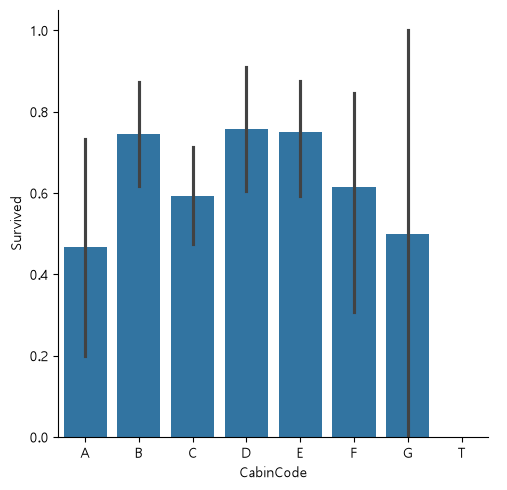

In [235]:
print(pd.crosstab(df['CabinCode'], df['Pclass']).to_string())

g = sns.catplot(x='CabinCode', y='Survived', data=df, kind='bar',
                order=sorted(df['CabinCode'].dropna().unique()))

**갑판 코드는 결국 객실 등급입니다**

A~E 갑판은 대부분 1등석, F~G는 2·3등석입니다.  
즉 `CabinCode` 는 `Pclass` 와 크게 겹칩니다.

> 설명 변수끼리 강하게 겹치면 모델에 둘 다 넣었을 때  
> **어느 쪽이 효과를 낸 것인지 구분할 수 없습니다.**  
> 하나를 빼거나 합치는 것을 검토합니다.

그래서 `Cabin` 에서 실제로 건질 것은 갑판 코드보다  
**3절에서 만든 `HasCabin`(기록 여부)** 쪽입니다.

---

## 9. 발견 사항 · 다음 단계 · 한계

### 발견 사항

번호를 매긴 **사실** 목록으로 정리하세요. 추측과 사실을 구분합니다.

1. 전체 생존률 38%, **타깃 살짝 불균형**
2. 생존률에 가장 영향 미치는 요인 - 성별 (여 74%, 남 18.9%), 그 다음 - 객실 등급
3. 성별 격차는 모든 객실 등급에서 유지됨 -> 두 변수를 독립적으로 볼 수 있다.
4. 항구별 생존률 차이는 사실 객실등급에 기반한 차이였다.
5. 큰 Fare 요금은 이상치가 아니라 티켓단위로 합쳐져 있던 문제였다.
6. Master 어린 남자아이를 뜻한다. (추가적인 정보 획득)

### 다음 단계 — 모델링에 쓸 변수

**사용할 변수** : `Sex` · `Pclass` · `Age` · `SibSp` · `Parch` · `LogFare` · `HasCabin` · `Embarked` · `TitleCode`

**제외할 변수와 이유**
- `PassengerId` · `Ticket` — 식별자. 정보가 없다
- `Name` — 원본은 제외하되 `TitleCode` 로 정보를 살렸다
- `Cabin` — 결측 77%. `HasCabin` 으로 대체

**만들 파생변수**
- `FamilySize = SibSp + Parch + 1`
- `IsAlone = (FamilySize == 1)`
- `LogFare = np.log1p(Fare)` — 왜도 완화
- `TitleCode` — 8절에서 완성

### 모델링 준비 체크리스트

- [x] 결측 처리 완료 + 근거 기록 (3절)
- [x] 이상치 판단 완료 — `Fare` 는 티켓 합계이므로 **보존** (4절)
- [x] 범주형 변수 인코딩 계획 수립 — `Sex`·`Embarked` 원-핫
- [x] 왜도 큰 변수 변환 여부 결정 — `Fare` 로그 변환
- [x] 타깃 불균형 확인 → 정확도 대신 **F1 · ROC-AUC**
- [x] 서로 강하게 상관된 변수 정리 — `Pclass` ↔ `CabinCode`
- [x] 데이터 누수 가능 변수 제외 — 해당 없음
- [x] 파생변수 후보 정리

In [ ]:
# TODO 파생변수를 실제로 만들어 최종 데이터프레임을 확인해 보세요.

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['LogFare'] = np.log1p(df['Fare'])
# df['LogFare'] = np.log1p(df['FarePerPerson'])

df.head(2).T

use_cols = ['Pclass', 'Sex', 'Age', 'Embarked', 'HasCabin',
            'SibSp', 'Parch', 'FamilySize', 'IsAlone', 
            'TitleCode', 'LogFare']
df[use_cols]

,Pclass,Sex,Age,SibSp,Parch,Embarked,HasCabin,TitleCode,FamilySize,IsAlone,LogFare
0,3,male,22.0,1,0,S,1,1,2,0,2.110213
1,1,female,38.0,1,0,C,0,3,2,0,4.280593
2,3,female,26.0,0,0,S,1,2,1,1,2.188856
3,1,female,35.0,1,0,S,0,3,2,0,3.990834
4,3,male,35.0,0,0,S,1,1,1,1,2.202765
...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,S,1,5,1,1,2.639057
887,1,female,19.0,0,0,S,0,2,1,1,3.433987
888,3,female,21.5,1,2,S,1,2,4,0,3.196630
889,1,male,26.0,0,0,C,0,1,1,1,3.433987


### 한계

이 데이터와 분석의 제약을 적으세요.

- 표본 891명으로 실제 탑승 인원의 일부. **표본 편향** 가능성이 있다.
- Age 결측 20%, Pclass, Sex의 중앙값으로 채웠는데, 보수적으로 데이터를 읽을 필요가 있다.
- 관측 데이터 특성 상, 인과 관계로 해석하는 것은 불가능하다.  
    여자라서 살았다.(X) 여성의 생존률이 높았다.(O)
- Fare는 Ticket 단위 합계라서 개인 요금으로 해석하면 이상치 취급될 수 있다.